## Úloha 2 - Šum v obraze

V této úloze se seznámíme se dvěma běžnými typy šumu v digitálním obraze: **Gaussovým šumem** a šumem **sůl a pepř**. Šum vzniká například při snímání nebo přenosu obrazu a zhoršuje jeho kvalitu. Naučíme se šum přidat, zobrazit a jednoduše potlačit.

## Import knihoven

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Testovací obrázek

1. vytvořte grayscale obrázek velikosti 100 x 100 pixelů (hodnoty 0–255, typ `uint8`)
1. na tmavé pozadí umístěte světlý obdélník nebo kříž
1. obrázek uložte do proměnné `img` a zobrazte pomocí `plt.imshow(..., cmap="gray")`

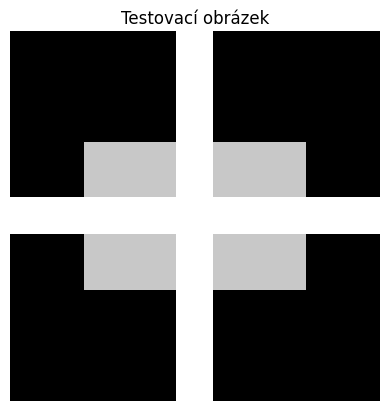

In [2]:
img = np.zeros((100, 100), dtype=np.uint8)
img[30:70, 20:80] = 200  # světlý obdélník
img[45:55, :] = 255      # vodorovná část kříže
img[:, 45:55] = 255      # svislá část kříže

plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Testovací obrázek")
plt.axis("off")
plt.show()

## Gaussův šum

Gaussův šum přidává ke každému pixelu náhodnou hodnotu z normálního (Gaussova) rozdělení.

1. pomocí `np.random.normal(0, sigma, img.shape)` vytvořte matici šumu
1. přičtěte šum k obrázku (převod na `float`) a ořízněte hodnoty do intervalu `[0, 255]` pomocí `np.clip`
1. výsledek převeďte zpět na `uint8`
1. zobrazte originál a zašuměný obrázek vedle sebe
1. vyzkoušejte různé hodnoty `sigma` (např. 10, 25, 50) a pozorujte rozdíl

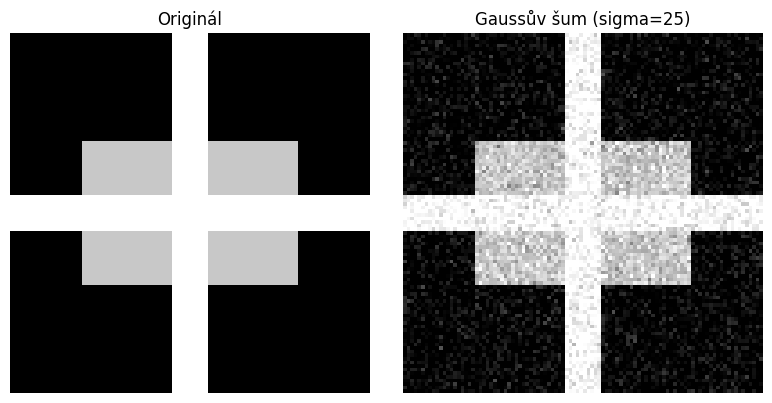

In [3]:
def add_gaussian_noise(img, sigma=25):
    noise = np.random.normal(0, sigma, img.shape)
    noisy = img.astype(float) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)


img_gaussian = add_gaussian_noise(img, sigma=25)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Originál")
axes[0].axis("off")
axes[1].imshow(img_gaussian, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Gaussův šum (sigma=25)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Šum sůl a pepř

Šum sůl a pepř náhodně nastaví malé množství pixelů na maximální hodnotu (sůl = bílá) nebo na nulu (pepř = černá).

1. vytvořte kopii obrázku `img`
1. náhodně vyberte např. 5 % pixelů a nastavte je na 255 (sůl) nebo 0 (pepř)
1. tip: použijte `np.random.rand(*img.shape)` a prahy podle poměru šumu
1. zobrazte originál a zašuměný obrázek vedle sebe
1. vyzkoušejte různé podíly šumu (např. 0.02, 0.05, 0.1)

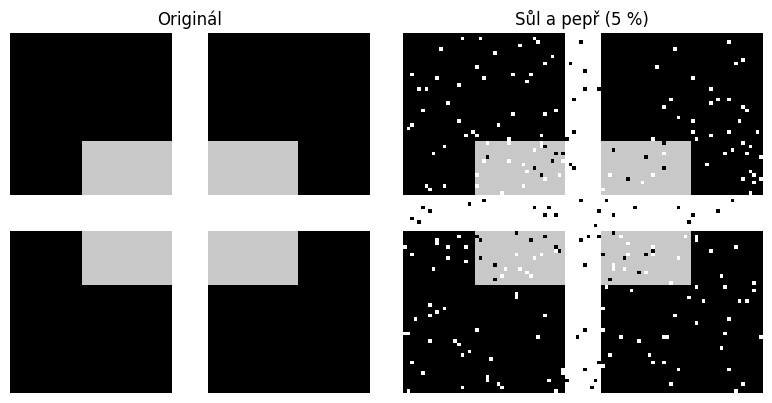

In [4]:
def add_salt_pepper(img, amount=0.05):
    out = img.copy()
    rnd = np.random.rand(*img.shape)
    out[rnd < amount / 2] = 0          # pepř
    out[rnd > 1 - amount / 2] = 255    # sůl
    return out


img_sp = add_salt_pepper(img, amount=0.05)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Originál")
axes[0].axis("off")
axes[1].imshow(img_sp, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Sůl a pepř (5 %)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Jednoduché odstranění šumu

1. na obrázek s Gaussovým šumem aplikujte `cv2.GaussianBlur` a výsledek zobrazte
1. na obrázek se šumem sůl a pepř aplikujte `cv2.medianBlur` a výsledek zobrazte
1. porovnejte, který filtr lépe funguje na který typ šumu
1. (volitelně) vyzkoušejte oba filtry i na „špatný“ typ šumu a pozorujte výsledek

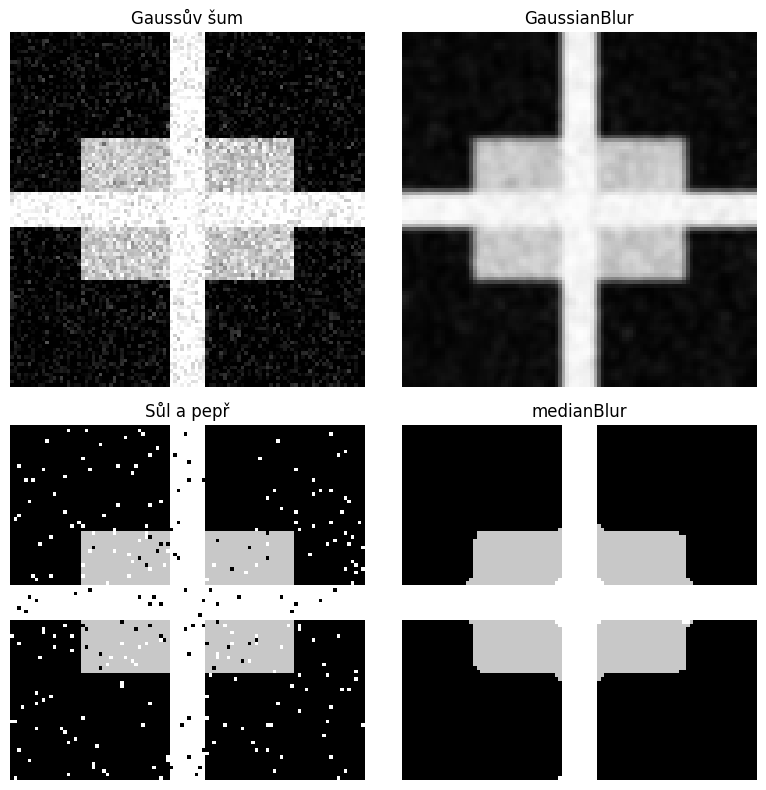

In [5]:
img_gaussian_denoised = cv2.GaussianBlur(img_gaussian, (5, 5), 0)
img_sp_denoised = cv2.medianBlur(img_sp, 5)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(img_gaussian, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Gaussův šum")
axes[0, 0].axis("off")
axes[0, 1].imshow(img_gaussian_denoised, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("GaussianBlur")
axes[0, 1].axis("off")
axes[1, 0].imshow(img_sp, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title("Sůl a pepř")
axes[1, 0].axis("off")
axes[1, 1].imshow(img_sp_denoised, cmap="gray", vmin=0, vmax=255)
axes[1, 1].set_title("medianBlur")
axes[1, 1].axis("off")
plt.tight_layout()
plt.show()